# Agglomerative Hierarchical Clustering

## What is it?
Agglomerative Hierarchical Clustering is an **unsupervised learning algorithm** that groups similar data points into clusters.

It follows a **bottom-up approach**:
- Starts with each data point as its own cluster.
- Repeatedly merges the two closest clusters.
- Continues until all points are merged into a single cluster.

---

## Working Steps
1. Treat each data point as a separate cluster.
2. Calculate the distance between all clusters.
3. Merge the two nearest clusters.
4. Repeat until only one cluster remains.
5. Use a **dendrogram** to decide the optimal number of clusters.

---

## Linkage Methods
- **Ward** – Minimizes the variance within clusters (most commonly used).
- **Single** – Uses the minimum distance between clusters.
- **Complete** – Uses the maximum distance between clusters.
- **Average** – Uses the average distance between clusters.

---

## Dendrogram
A dendrogram is a tree-like diagram that shows how clusters are merged.

- Height of the merge = Distance between clusters.
- Draw a horizontal line to choose the number of clusters.

---

## Advantages
- No need to specify the number of clusters initially.
- Easy to visualize using a dendrogram.
- Works well for small datasets.

---

## Disadvantages
- Slow for large datasets.
- Sensitive to noise and outliers.
- Once clusters are merged, they cannot be split.

---

## Applications
- Customer Segmentation
- Document Clustering
- Image Segmentation
- Gene Expression Analysis

---

## Scikit-learn Example

```python
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(X)
```

In [1]:
import pandas as pd

In [2]:
# Load the data using pandas
df = pd.read_csv("Mall_Customers.csv")

In [3]:
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


### Drop Irelevant columns and Map Species Column

In [5]:
df = df.drop(["CustomerID"], axis=1)

In [6]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

In [7]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


# Scale the data using StandardScaler

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [9]:
df_scaled = pd.DataFrame(X_scaled, columns=df.columns)

In [10]:
df_scaled.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980


In [27]:
data = df.iloc[:, 1:]
data.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


### Plot Dendrogram to find the optimal number of clusters

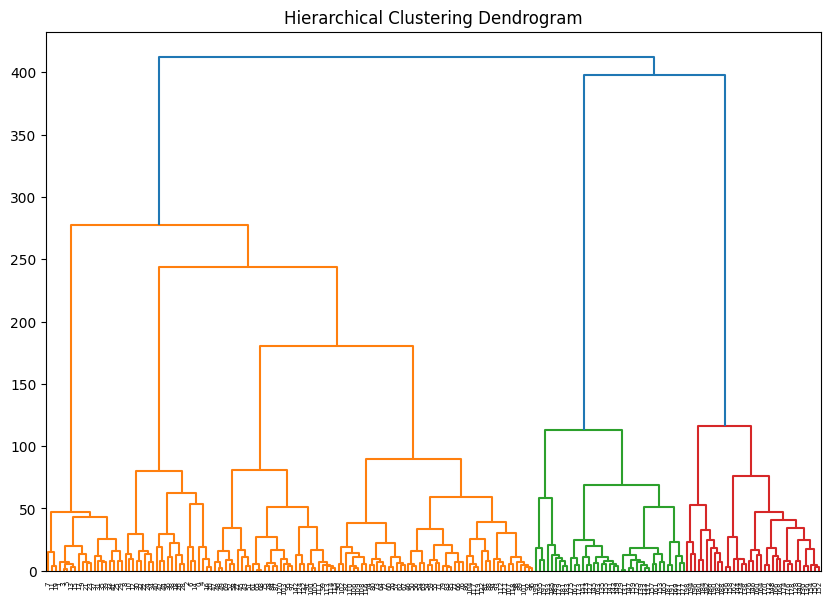

In [28]:
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.title('Hierarchical Clustering Dendrogram')
dend = shc.dendrogram(shc.linkage(data, method='ward'))

plt.show()

### Perform Agglomerative Hierarchical Clustering

In [29]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5, linkage='ward')

labels_ = cluster.fit_predict(data)

In [30]:
labels_

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 0, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 0,
       4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2])

### Visualize the clusters

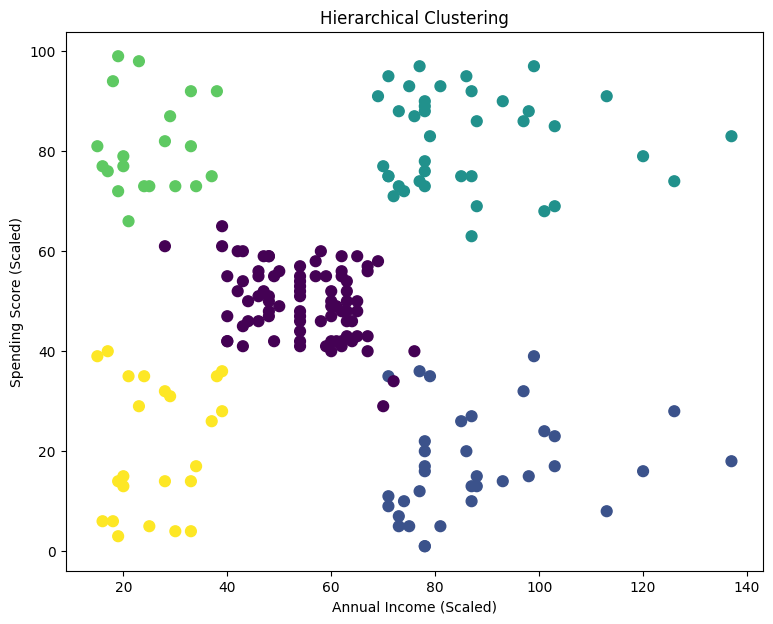

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))

plt.scatter(
    data.iloc[:, 1],
    data.iloc[:, 2],
    c=cluster.labels_,
    s=60
)

plt.title("Hierarchical Clustering")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")

plt.show()